***Bulf and Business problem ***

-Group 20: Xuanhong Chen and Wenziying Chen
-Business Problem: Limited Access to Cervical Cancer Screening and Early Detection Services

-Description: Many women worldwide are at risk of cervical cancer, a serious disease caused by abnormal cell growth in the cervix. However, a significant business problem arises from the limited access to cervical cancer screening and early detection services. Without timely screening, cases of cervical cancer may go undetected, leading to late-stage diagnoses and decreased chances of survival. This problem highlights the need for improved accessibility to screening tools, such as pap smears and HPV testing, as well as the implementation of efficient healthcare systems that prioritize early detection and treatment. By addressing this issue, healthcare providers and organizations can contribute to reducing the incidence and mortality rates of cervical cancer.
-Model and Explian：
In the given dataset, there are four target variables related to cervical cancer risk assessment: Hinselmann, Schiller, Citology, and Biopsy. To simplify the modeling process, a new variable called cervical_cancer has been created by summing up the values of these four variables. The cervical_cancer variable ranges from 0 to 4, representing different levels of risk. A value of 0 indicates no risk, while a value of 4 represents a higher level of risk. Therefore, the final class or target variables in the dataset are 0, 1, 2, 3, and 4, which correspond to the different risk levels associated with cervical cancer. This approach allows for a consolidated representation of the overall risk level, simplifying the modeling process and facilitating the analysis of cervical cancer risk factors.

#**Libraries**

In [ ]:
# Basic libraries
import pandas as pd
import numpy as np
from subprocess import check_output
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import math

In [ ]:
!pip install sweetviz     # You may need to pip install sweetviz
import sweetviz as sv

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
# import libraries
!pip install -q pycaret autoviz psynlig
from pycaret.regression import *
from autoviz.AutoViz_Class import AutoViz_Class

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 483.5/483.5 kB 9.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.0/150.0 kB 15.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.2/81.2 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.5/212.5 kB 18.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 11.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 4.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 55.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━

Imported v0.1.603. After importing, execute '%matplotlib inline' to display charts in Jupyter.
    AV = AutoViz_Class()
    dfte = AV.AutoViz(filename, sep=',', depVar='', dfte=None, header=0, verbose=1, lowess=False,
               chart_format='svg',max_rows_analyzed=150000,max_cols_analyzed=30, save_plot_dir=None)
Update: verbose=0 displays charts in your local Jupyter notebook.
        verbose=1 additionally provides EDA data cleaning suggestions. It also displays charts.
        verbose=2 does not display charts but saves them in AutoViz_Plots folder in local machine.
        chart_format='bokeh' displays charts in your local Jupyter notebook.
        chart_format='server' displays charts in your browser: one tab for each chart type
        chart_format='html' silently saves interactive HTML files in your local machine


#**Read Data**

In [ ]:
import numpy as np

#read
from google.colab import drive
drive.mount('/content/drive')

# Read
file_ ="/content/drive/MyDrive/risk_factors_cervical_cancer.csv"
df = pd.read_csv(file_) # read in csv file
df


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,?,?,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
853,34,3.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
854,32,2.0,19.0,1.0,0.0,0.0,0.0,1.0,8.0,0.0,...,?,?,0,0,0,0,0,0,0,0
855,25,2.0,17.0,0.0,0.0,0.0,0.0,1.0,0.08,0.0,...,?,?,0,0,0,0,0,0,1,0
856,33,2.0,24.0,2.0,0.0,0.0,0.0,1.0,0.08,0.0,...,?,?,0,0,0,0,0,0,0,0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

# replace '?' with NaN
df = df.replace('?', np.nan)

print(df)

     Age Number of sexual partners First sexual intercourse  \
0     18                       4.0                     15.0   
1     15                       1.0                     14.0   
2     34                       1.0                      NaN   
3     52                       5.0                     16.0   
4     46                       3.0                     21.0   
..   ...                       ...                      ...   
853   34                       3.0                     18.0   
854   32                       2.0                     19.0   
855   25                       2.0                     17.0   
856   33                       2.0                     24.0   
857   29                       2.0                     20.0   

    Num of pregnancies Smokes Smokes (years) Smokes (packs/year)  \
0                  1.0    0.0            0.0                 0.0   
1                  1.0    0.0            0.0                 0.0   
2                  1.0    0.0          

In [ ]:
import pandas as pd
from sklearn.impute import KNNImputer

# create a KNN imputer object
imputer = KNNImputer(n_neighbors=5)

# impute missing values in the DataFrame
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

print(df_imputed)


      Age  Number of sexual partners  First sexual intercourse  \
0    18.0                        4.0                      15.0   
1    15.0                        1.0                      14.0   
2    34.0                        1.0                      23.0   
3    52.0                        5.0                      16.0   
4    46.0                        3.0                      21.0   
..    ...                        ...                       ...   
853  34.0                        3.0                      18.0   
854  32.0                        2.0                      19.0   
855  25.0                        2.0                      17.0   
856  33.0                        2.0                      24.0   
857  29.0                        2.0                      20.0   

     Num of pregnancies  Smokes  Smokes (years)  Smokes (packs/year)  \
0                   1.0     0.0             0.0                  0.0   
1                   1.0     0.0             0.0                

#Missing value

In [ ]:
print("HEAD of df\n", df.head(20))
print("\nTAIL of df\n", df.tail())
# Shape of DataFrame
print("\nSHAPE of df\n", df.shape)

HEAD of df
     Age Number of sexual partners First sexual intercourse Num of pregnancies  \
0    18                       4.0                     15.0                1.0   
1    15                       1.0                     14.0                1.0   
2    34                       1.0                      NaN                1.0   
3    52                       5.0                     16.0                4.0   
4    46                       3.0                     21.0                4.0   
5    42                       3.0                     23.0                2.0   
6    51                       3.0                     17.0                6.0   
7    26                       1.0                     26.0                3.0   
8    45                       1.0                     20.0                5.0   
9    44                       3.0                     15.0                NaN   
10   44                       3.0                     26.0                4.0   
11   27         

In [ ]:
# Checks

# Check data types
print(df.info())

# Check for missing values
print('\n\nMissing Values\n',df.isnull().sum(axis=0))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age                                 858 non-null    int64 
 1   Number of sexual partners           832 non-null    object
 2   First sexual intercourse            851 non-null    object
 3   Num of pregnancies                  802 non-null    object
 4   Smokes                              845 non-null    object
 5   Smokes (years)                      845 non-null    object
 6   Smokes (packs/year)                 845 non-null    object
 7   Hormonal Contraceptives             750 non-null    object
 8   Hormonal Contraceptives (years)     750 non-null    object
 9   IUD                                 741 non-null    object
 10  IUD (years)                         741 non-null    object
 11  STDs                                753 non-null    object

#Dropping unrelated variable

In [ ]:
df.drop(['STDs: Time since first diagnosis','STDs: Time since last diagnosis'],inplace=True,axis=1)

In [ ]:
numerical_df = ['Age', 'Number of sexual partners', 'First sexual intercourse','Num of pregnancies', 'Smokes (years)',
                'Smokes (packs/year)','Hormonal Contraceptives (years)','IUD (years)','STDs (number)']
categorical_df = ['Smokes','Hormonal Contraceptives','IUD','STDs','STDs:condylomatosis','STDs:cervical condylomatosis',
                  'STDs:vaginal condylomatosis','STDs:vulvo-perineal condylomatosis', 'STDs:syphilis',
                  'STDs:pelvic inflammatory disease', 'STDs:genital herpes','STDs:molluscum contagiosum', 'STDs:AIDS',
                  'STDs:HIV','STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis','Dx:Cancer', 'Dx:CIN',
                  'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller','Citology', 'Biopsy']

In [ ]:
for feature in numerical_df:
    print(feature,'',pd.to_numeric(df[feature], errors='coerce').mean())
    feature_mean = round(pd.to_numeric(df[feature], errors='coerce').mean(),1)
    df[feature] = pd.to_numeric(df[feature], errors='coerce').fillna(feature_mean)

Age  26.82051282051282
Number of sexual partners  2.527644230769231
First sexual intercourse  16.995299647473562
Num of pregnancies  2.275561097256858
Smokes (years)  1.219721412585799
Smokes (packs/year)  0.4531439506492308
Hormonal Contraceptives (years)  2.2564192013893334
IUD (years)  0.5148043184885289
STDs (number)  0.17662682602921648


In [ ]:
for feature in categorical_df:
    df[feature] = df[feature].astype('category').cat.codes
    df[feature] = df[feature].fillna(1)

In [ ]:
category_df = ['Hinselmann', 'Schiller','Citology', 'Biopsy']

#**Visualize**

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:447: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=figsize)


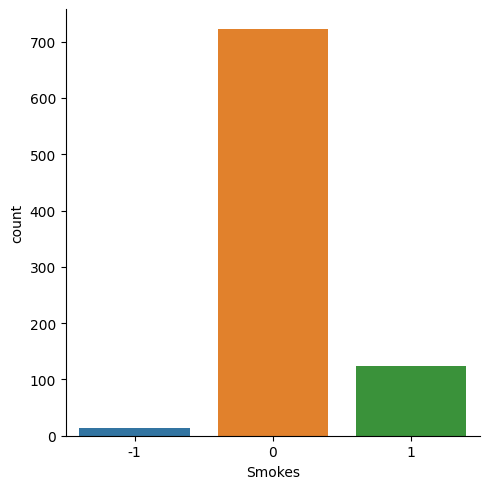

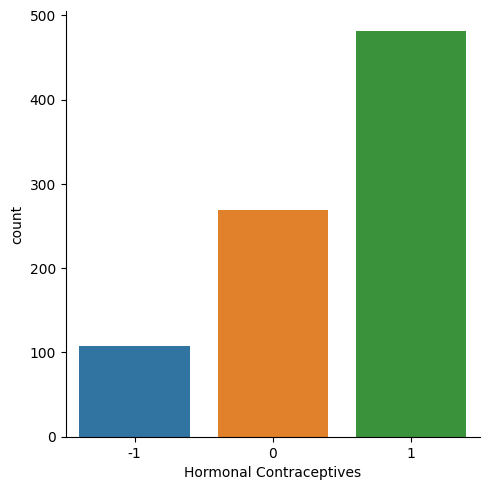

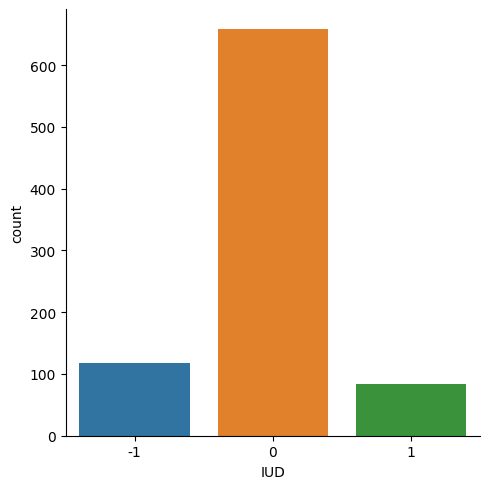

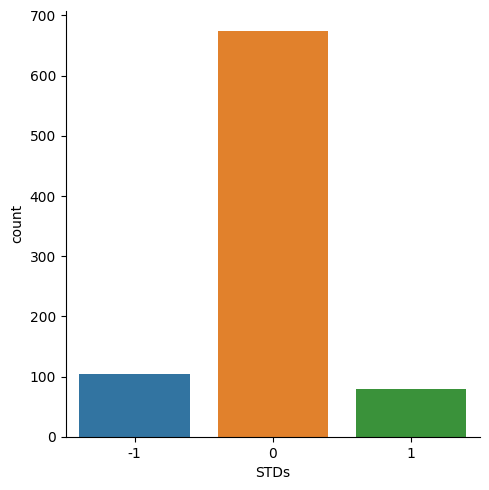

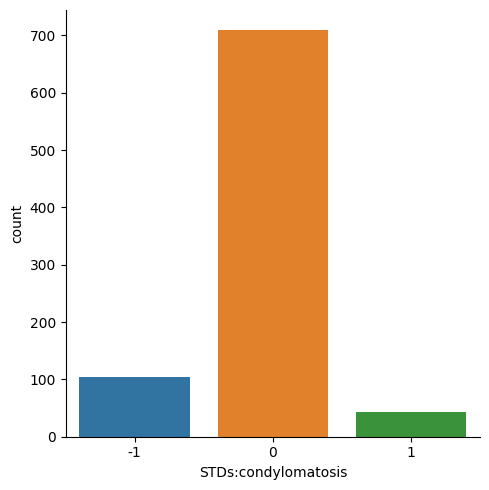

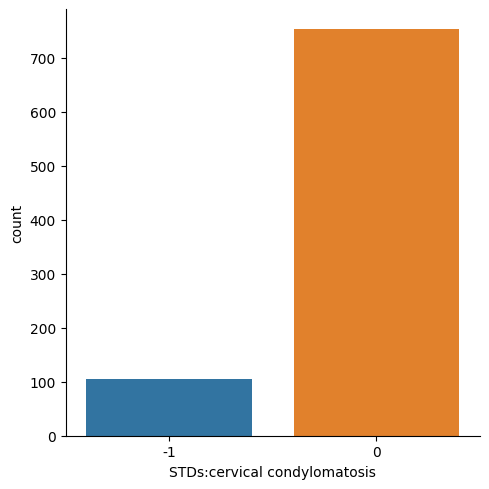

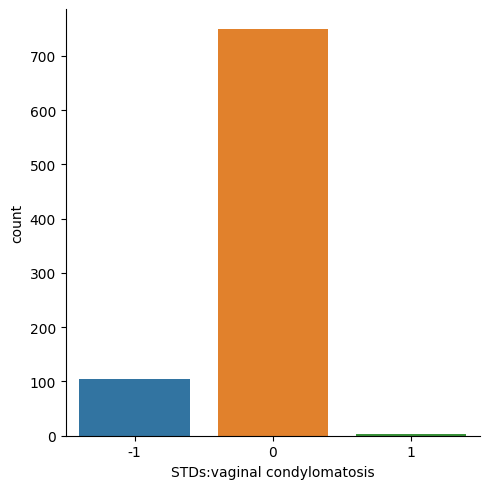

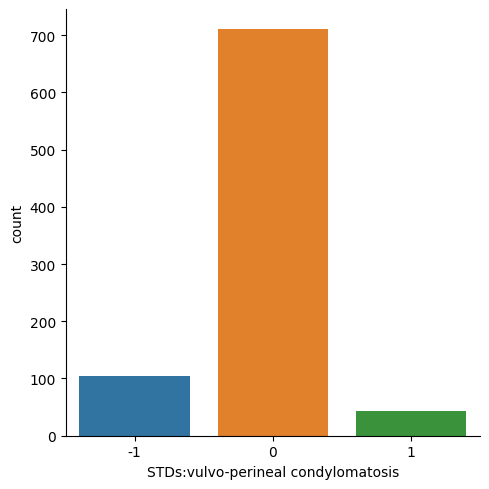

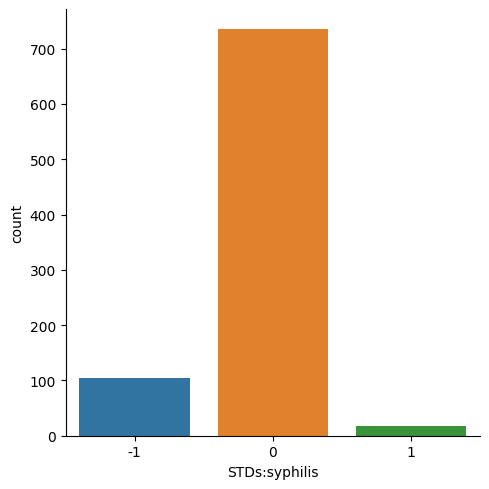

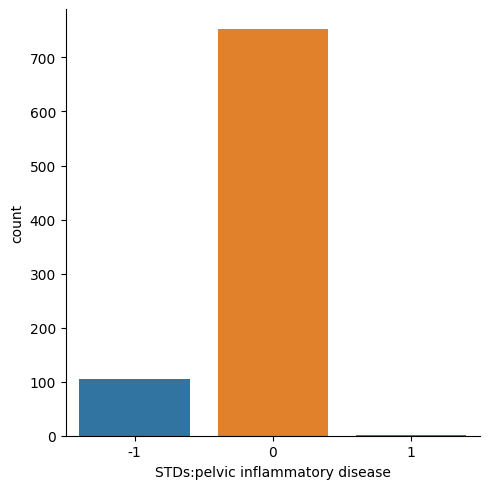

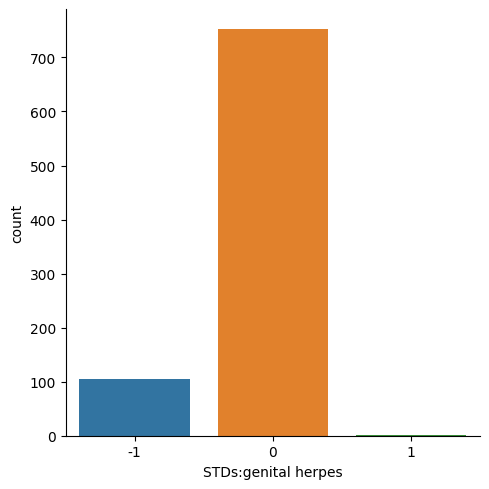

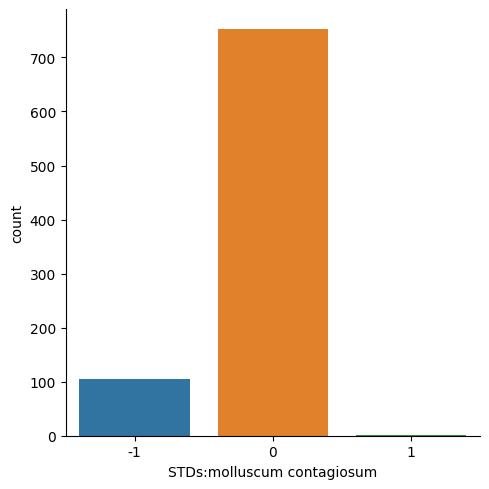

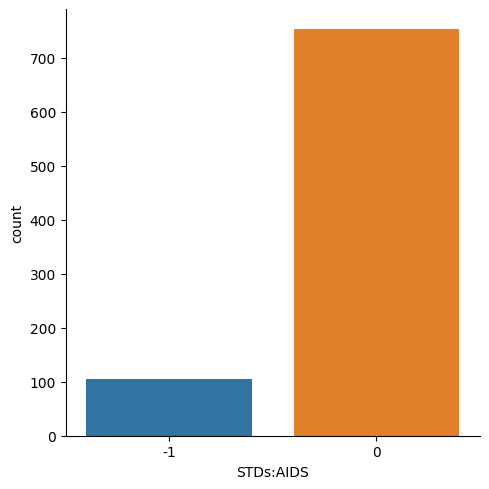

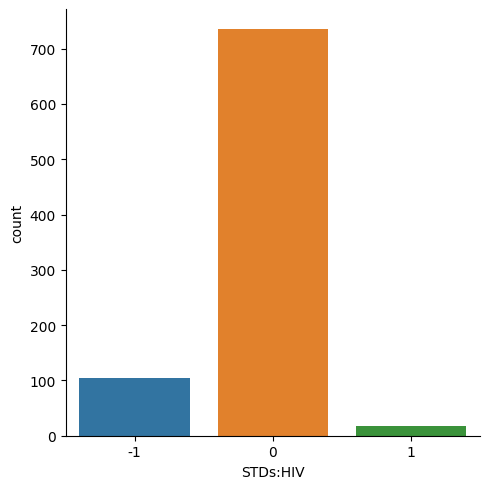

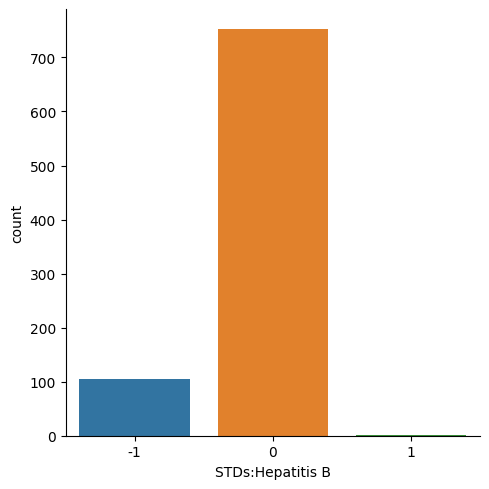

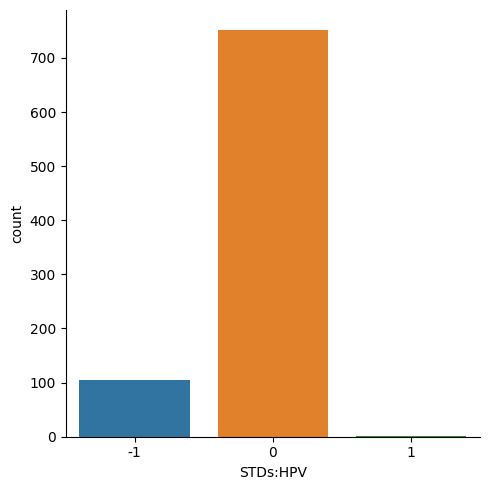

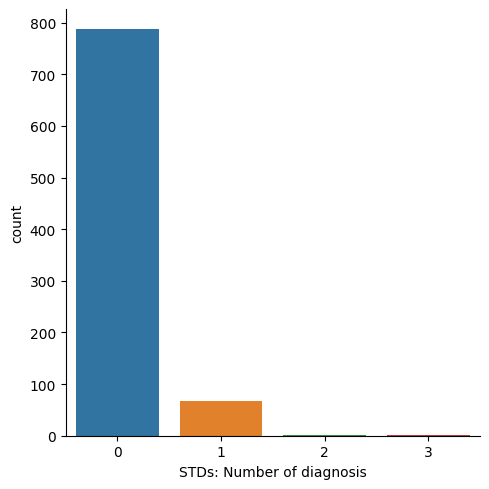

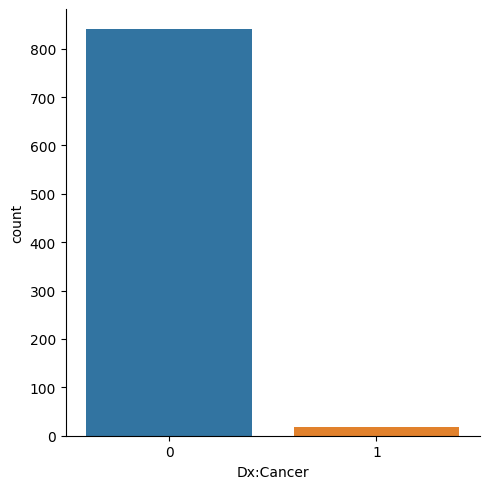

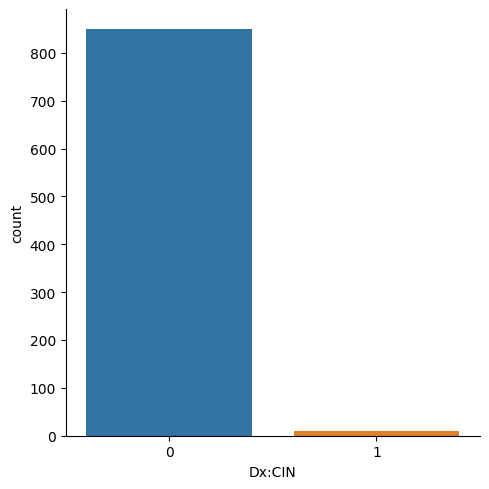

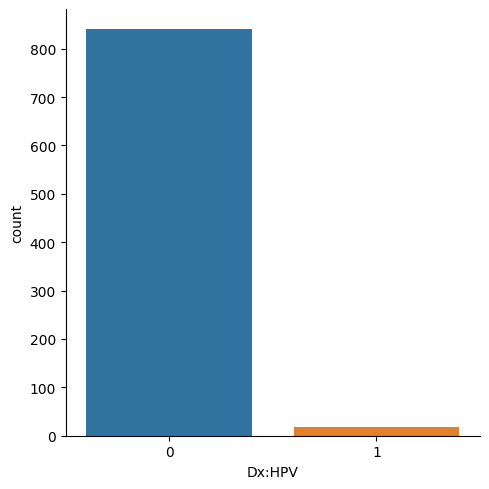

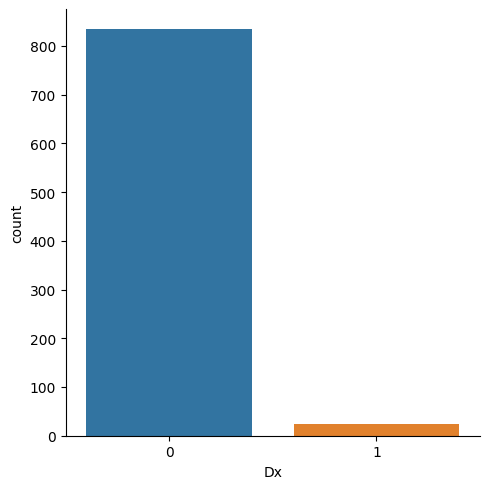

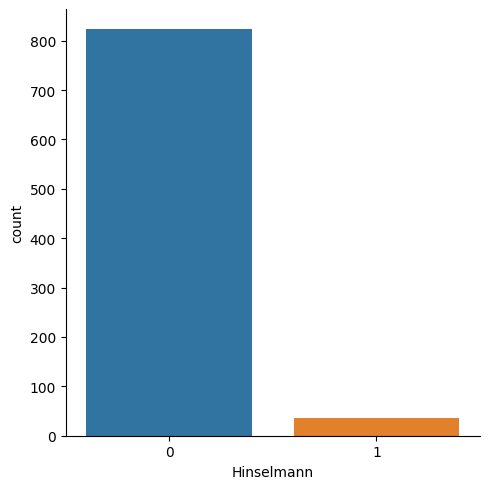

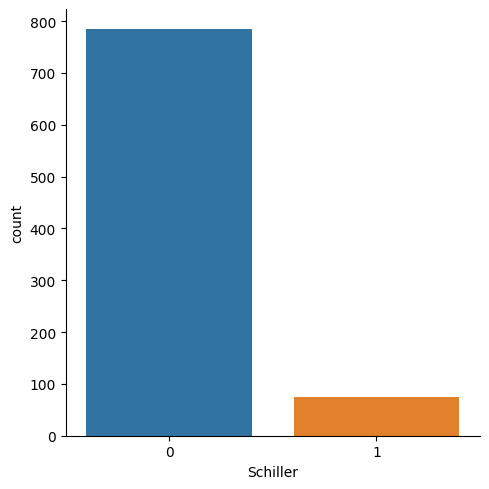

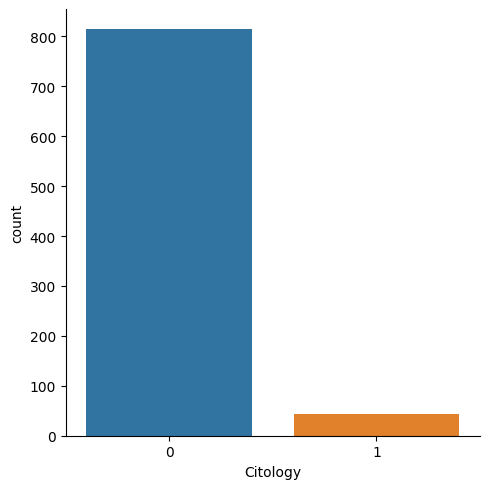

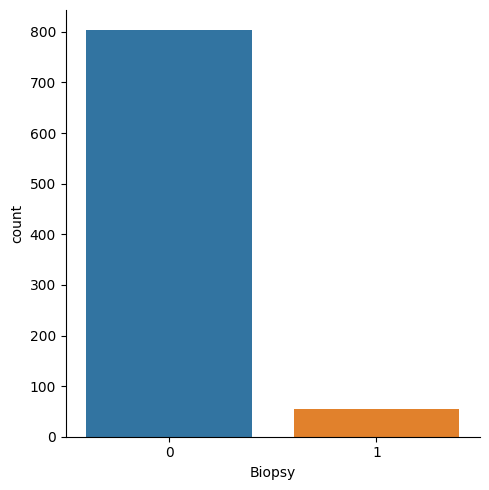

In [ ]:
import seaborn as sns

for feature in categorical_df:
   sns.catplot(x=feature,data=df,kind='count')


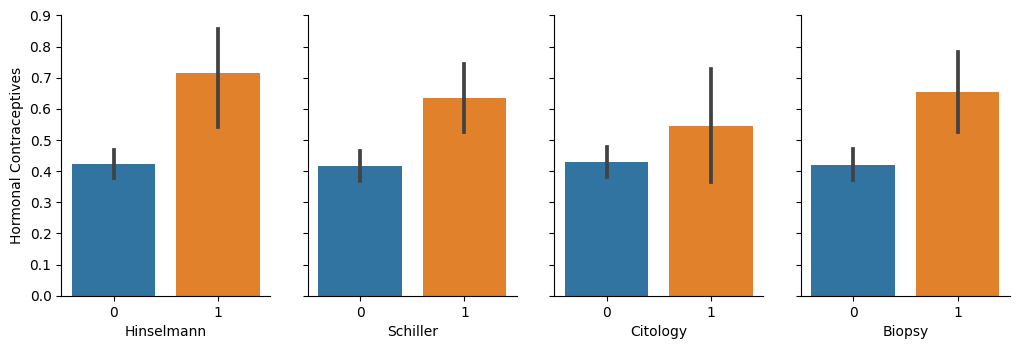

In [ ]:
g = sns.PairGrid(df,
                 y_vars=['Hormonal Contraceptives'],
                 x_vars= category_df,
                 aspect=.75, height=3.5)
g.map(sns.barplot, palette="pastel");

In [ ]:
df['Number of sexual partners'] = round(pd.to_numeric(df['Number of sexual partners'], errors='coerce'))
df['First sexual intercourse'] = pd.to_numeric(df['First sexual intercourse'], errors='coerce')
df['Num of pregnancies'] = round(pd.to_numeric(df['Num of pregnancies'], errors='coerce'))
df['Smokes'] = pd.to_numeric(df['Smokes'], errors='coerce')
df['Smokes (years)'] = pd.to_numeric(df['Smokes (years)'], errors='coerce')

print('minimum:',min(df['Hormonal Contraceptives (years)']))
print('maximum:',max(df['Hormonal Contraceptives (years)']))

minimum: 0.0
maximum: 30.0


Mean age of the Women facing the risk of Cervical cancer 26.82051282051282


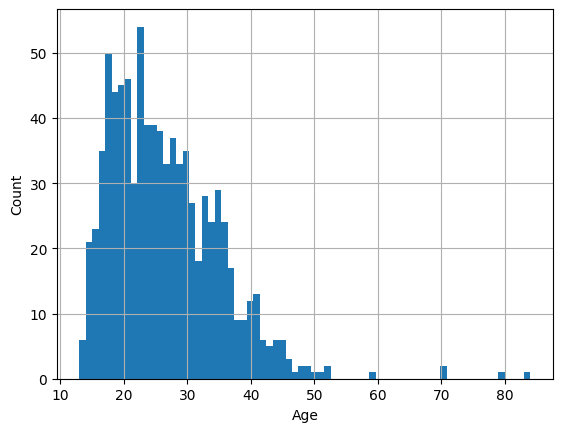

In [ ]:
df['Age'].hist(bins=70)
plt.xlabel('Age')
plt.ylabel('Count')
print('Mean age of the Women facing the risk of Cervical cancer',df['Age'].mean())

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:848: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:848: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:848: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:848: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_a

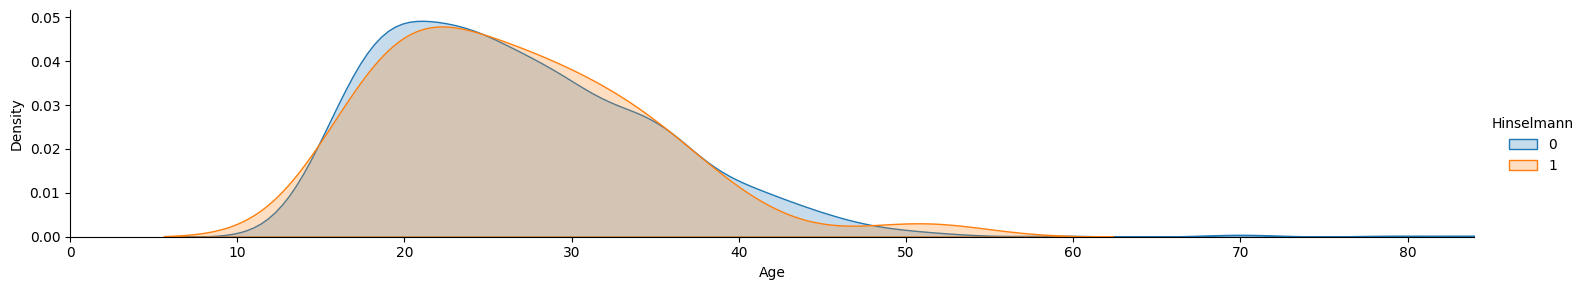

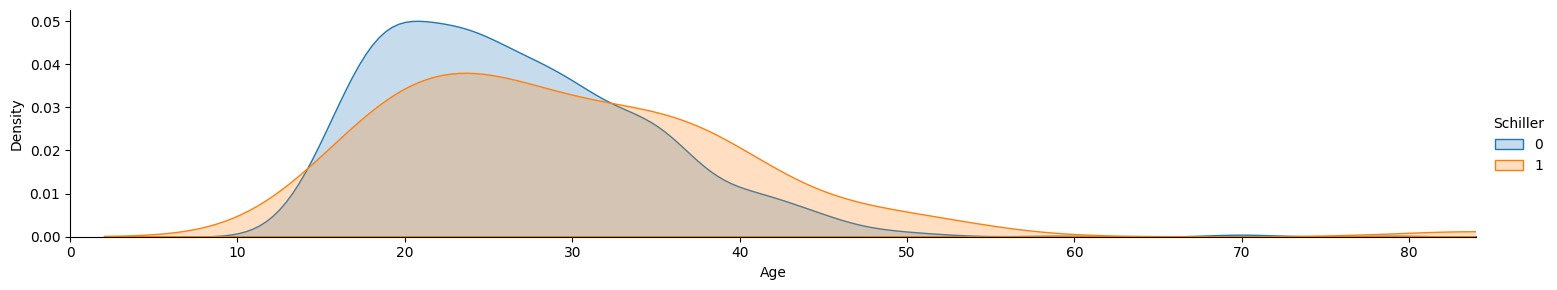

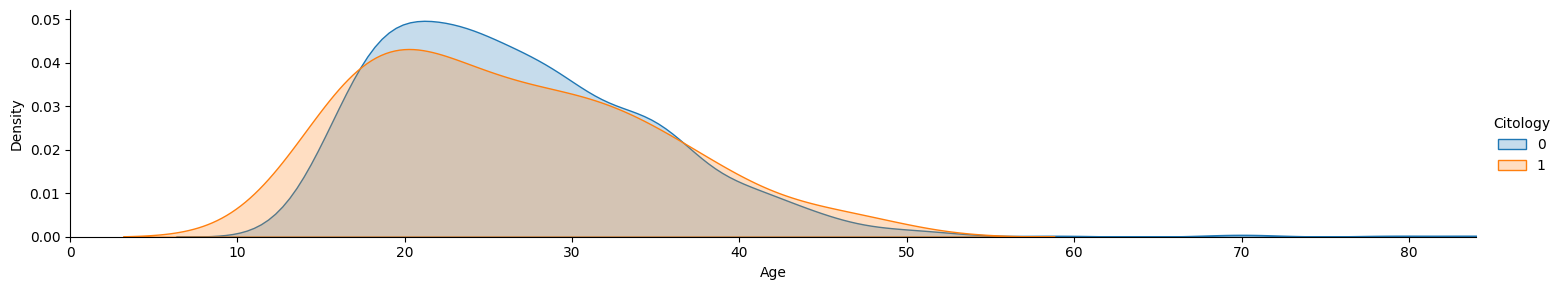

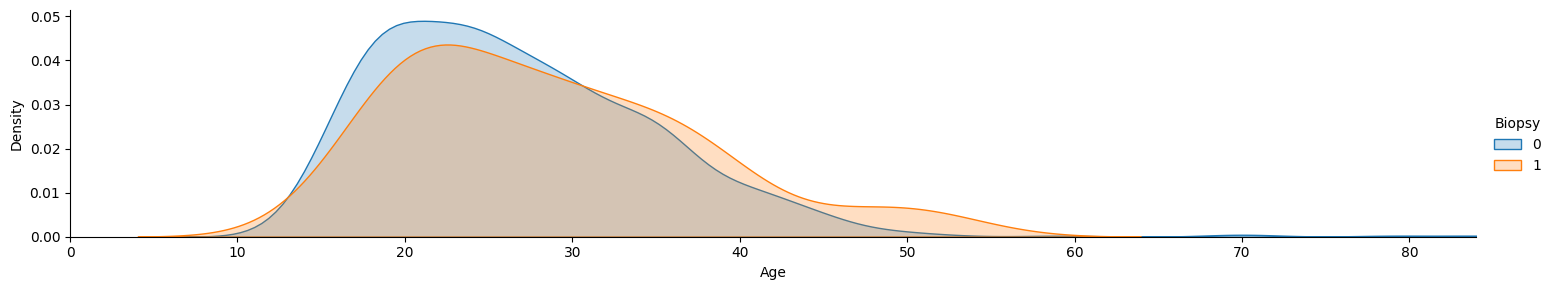

In [ ]:
#From the above plots it can be seen that the mean age of the women facing the risk of cervicakl cancer is 26.
# Also the women with the age in range of 20 to 35 have the highest chances of developing the risk of cervical cancer.
#The peaks at age of 50 and the furthur extension of the density plot indicate that some of the women face the risk of cervical cancer even at that age.

for feature in category_df:
 as_fig = sns.FacetGrid(df,hue=feature,aspect=5)
 as_fig.map(sns.kdeplot,'Age',shade=True)
 oldest = df['Age'].max()
 as_fig.set(xlim=(0,oldest))
 as_fig.add_legend()

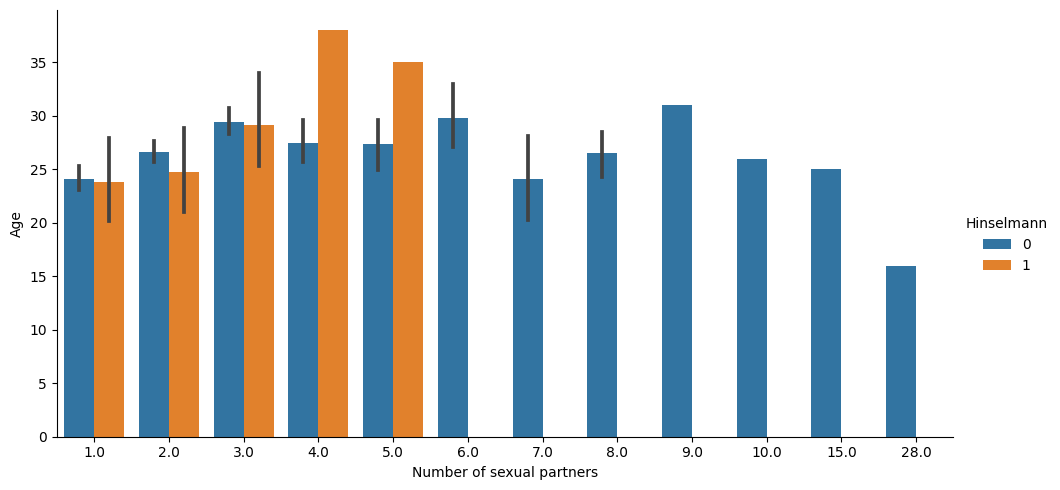

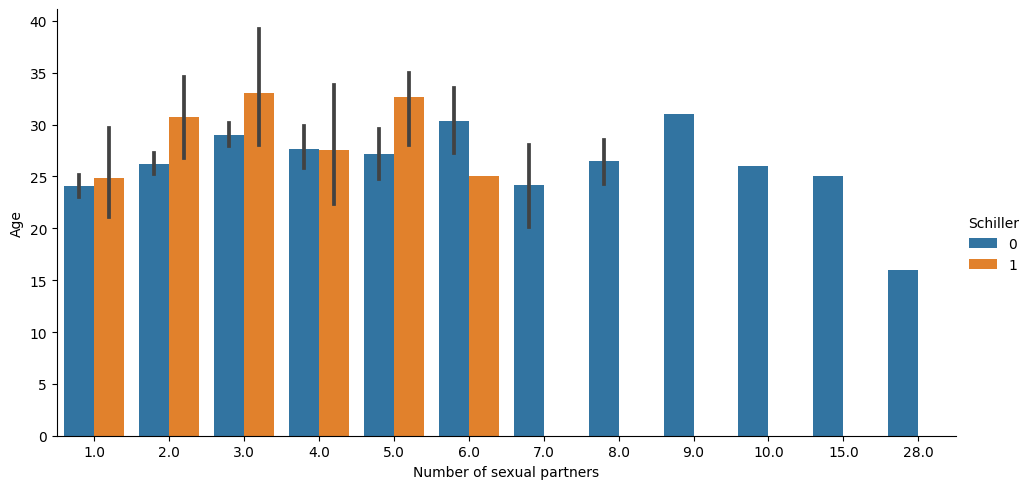

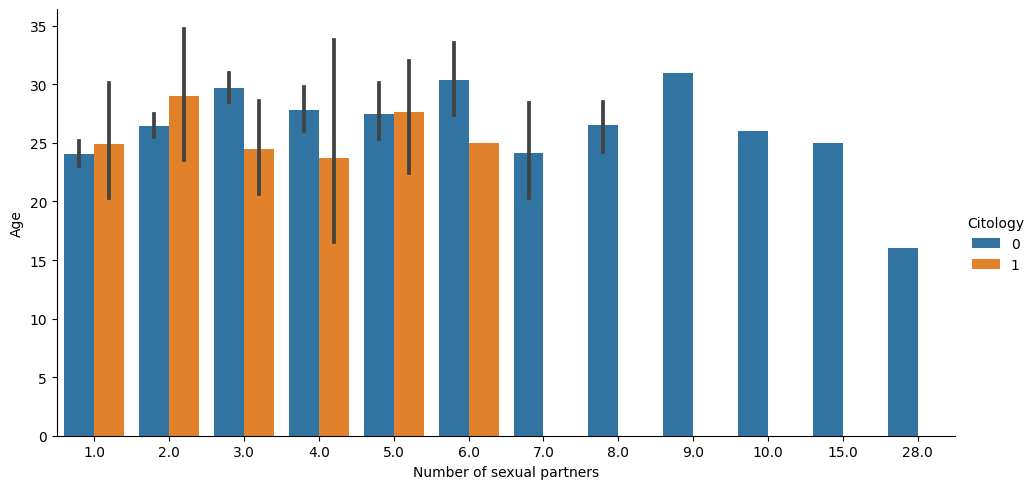

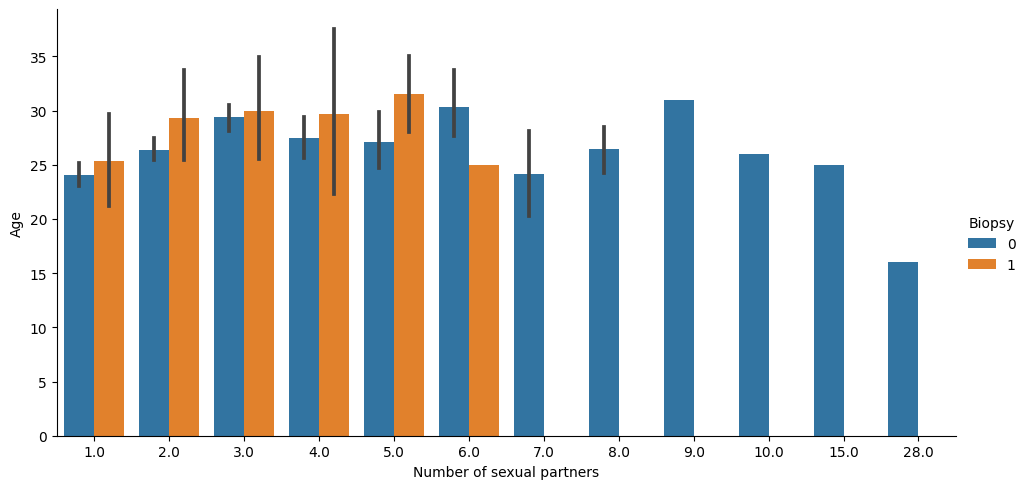

In [ ]:
for feature in category_df:
    sns.catplot(x='Number of sexual partners', y='Age', hue=feature, data=df, aspect=1.95, kind='bar');

In [ ]:
df['First sexual intercourse'] = pd.to_numeric(df['First sexual intercourse'], errors='coerce')
print('Mean age of the women who started the sexual intercourse',df['First sexual intercourse'].mean())

Mean age of the women who started the sexual intercourse 16.995337995337994


/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:848: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:848: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:848: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:848: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_a

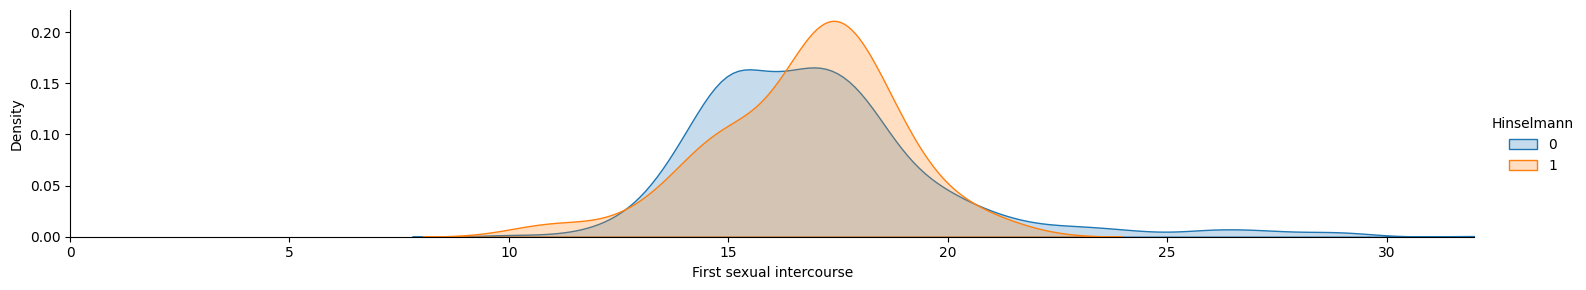

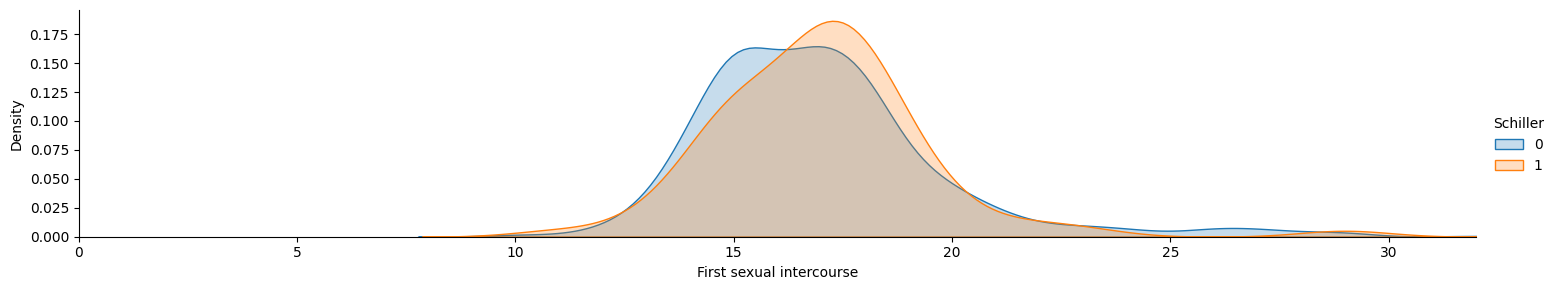

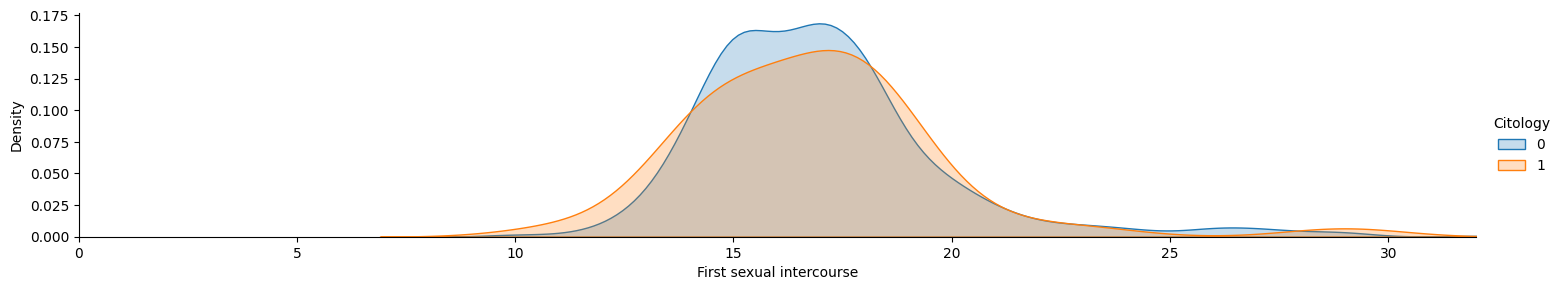

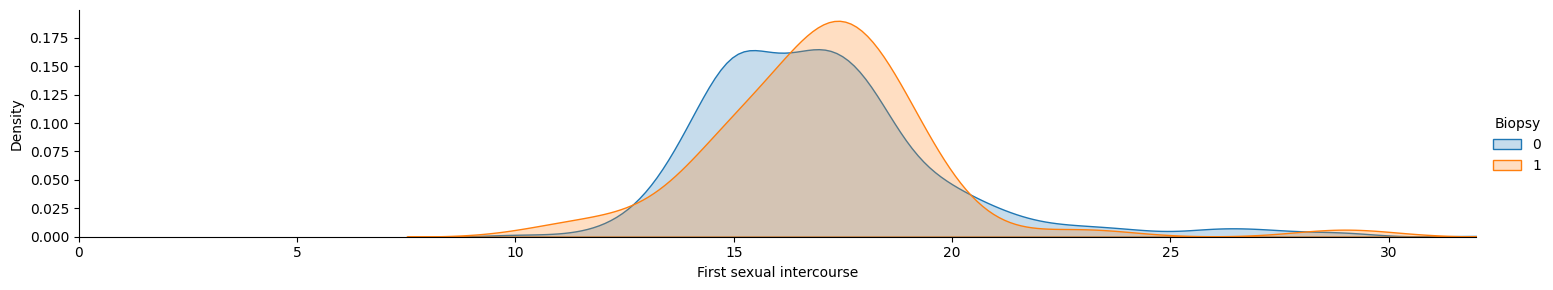

In [ ]:
for feature in category_df:

 as_fig = sns.FacetGrid(df,hue=feature,aspect=5)

 as_fig.map(sns.kdeplot,'First sexual intercourse',shade=True)

 oldest = df['First sexual intercourse'].max()

 as_fig.set(xlim=(0,oldest))

 as_fig.add_legend()


#Heatmap

In [ ]:
preg_table = pd.crosstab(index=df["Hinselmann"],
                          columns=[df["Num of pregnancies"],df['Number of sexual partners']])

<Axes: xlabel='Num of pregnancies-Number of sexual partners', ylabel='Hinselmann'>

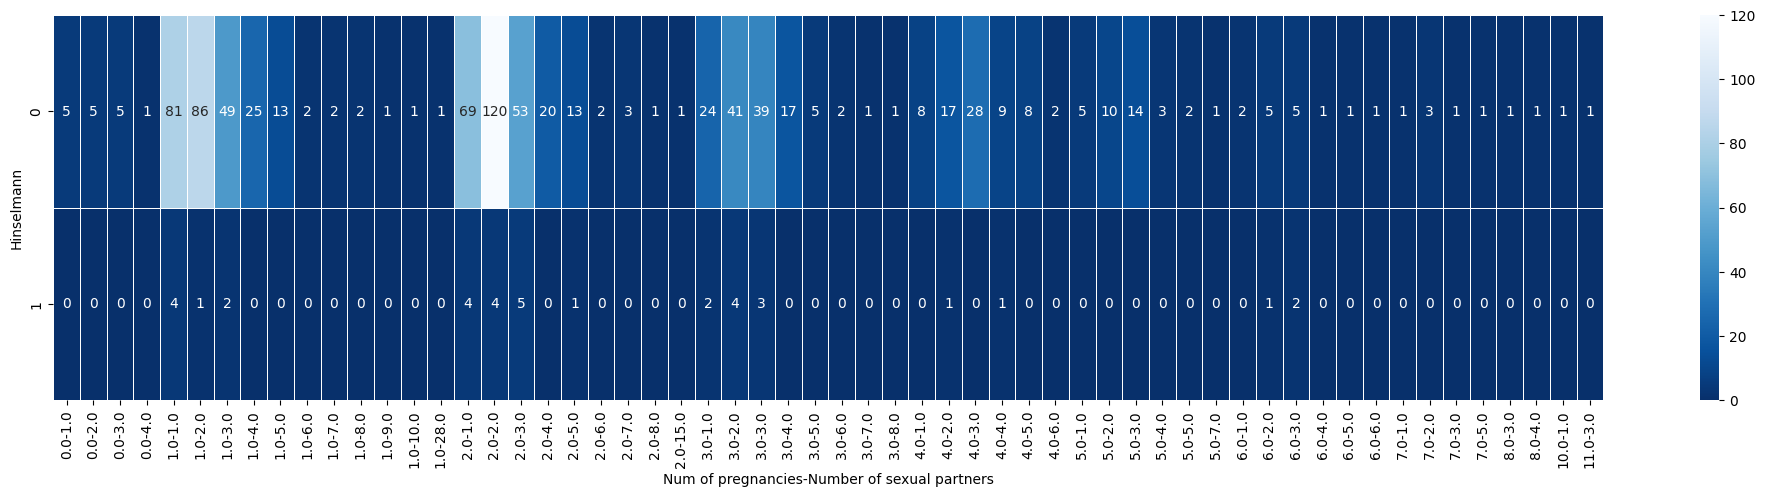

In [ ]:
fig, ax = plt.subplots(figsize=(25,5))
sns.heatmap(preg_table,annot=True, fmt="d",cmap="Blues_r",linewidths=0.5,ax=ax)

In [ ]:
##### checking to see if there is any relation between number of pregnancies and number of sexual partners
df['Number of sexual partners'].corr(df['Num of pregnancies'])

0.07743921250933397

#Correlation

In [ ]:
df['Smokes (packs/year)'] = pd.to_numeric(df['Smokes (packs/year)'])
print('Correlation between Smokes and Smokes (years) feature:', df['Smokes'].corr(df['Smokes (years)']))
print('Correlation between Smokes and Smokes (packs/year) feature:', df['Smokes'].corr(df['Smokes (packs/year)']))

Correlation between Smokes and Smokes (years) feature: 0.6716653932543937
Correlation between Smokes and Smokes (packs/year) feature: 0.45713671508127


In [ ]:
#dropping smoke value since Smokes (years) will represent the Smokes column because Smoke (years)
# column has non-zero value only when Smokes column has non-zero value.
# Also, the predictions depends on the number of years the person is smoking rather than just whether the smokes or not.

df.drop('Smokes',axis=1,inplace=True)

In [ ]:
smokes_table = pd.crosstab(index=df["Schiller"],
                          columns=(df["Smokes (years)"]))

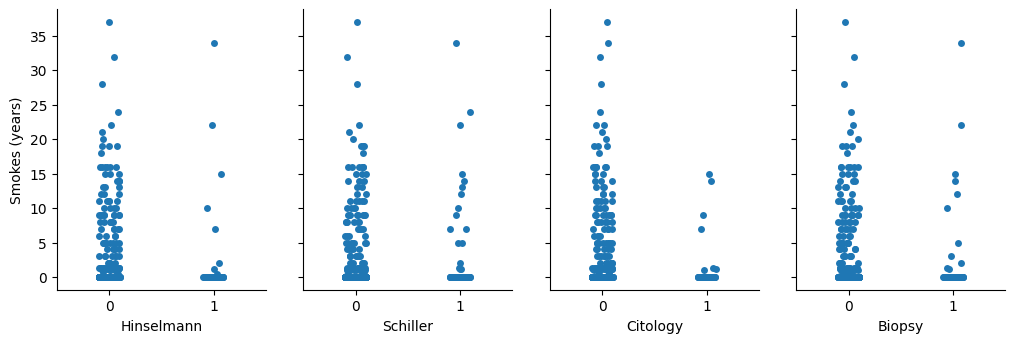

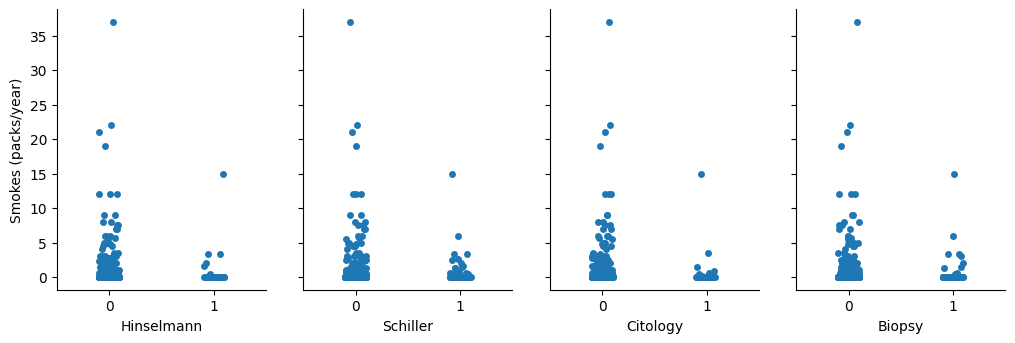

In [ ]:
g = sns.PairGrid(df,
                 y_vars=['Smokes (years)'],
                 x_vars= category_df,
                 aspect=.75, height=3.5)
g.map(sns.stripplot, palette="winter");

g = sns.PairGrid(df,
                 y_vars=['Smokes (packs/year)'],
                 x_vars= category_df,
                 aspect=.75, height=3.5)
g.map(sns.stripplot, palette="winter");


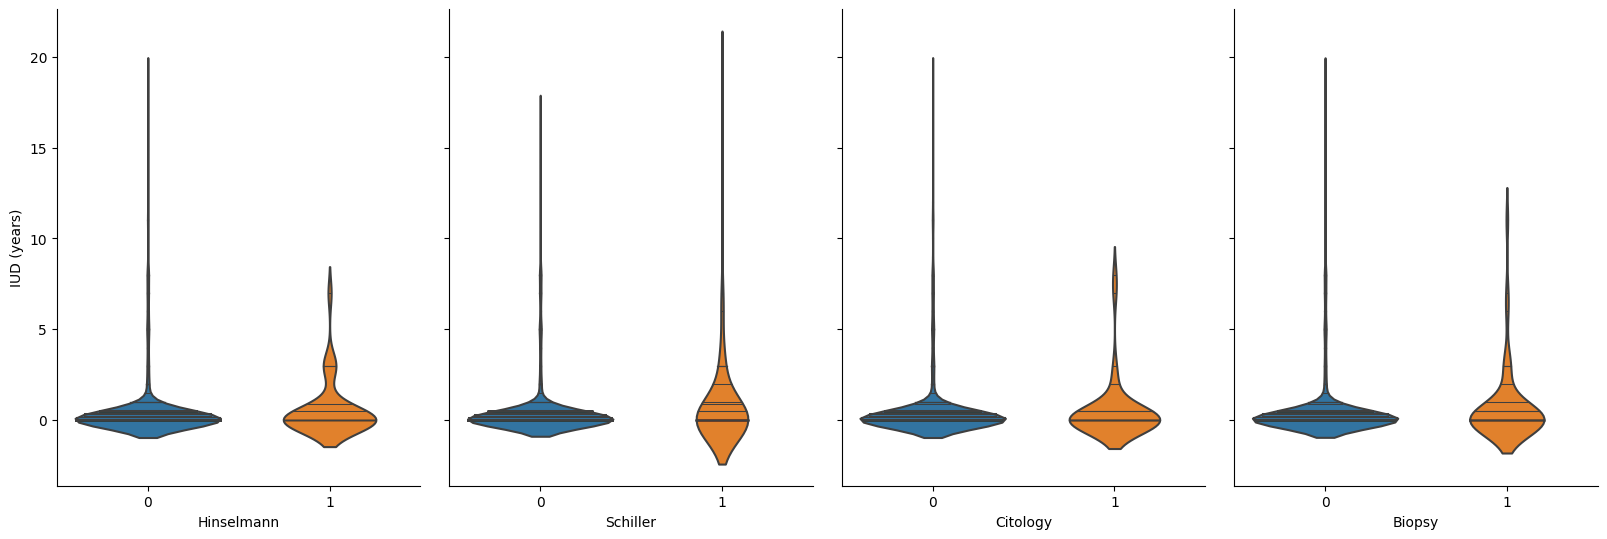

In [ ]:
#Women Who Use IUDs May Have Lower Risk of Cervical Cancer.
g = sns.PairGrid(df,
                 y_vars=['IUD (years)'],
                 x_vars= category_df,
                 aspect=.75, height=5.5)
g.map(sns.violinplot, palette="Accent",inner='stick');

In [ ]:
df_features = df.drop(['Hinselmann', 'Schiller', 'Citology','Biopsy'],axis=1)
df_label = pd.DataFrame(data=df['Hinselmann'])

In [ ]:
df_label['Schiller'] = df['Schiller']
df_label['Citology'] = df['Citology']
df_label['Biopsy'] =df['Biopsy']

In [ ]:
def cervical_cancer(cancer_label):

    hil, sch, cit, bio = cancer_label

    return hil+sch+cit+bio

df_label['cervical_cancer'] = df_label[['Hinselmann', 'Schiller', 'Citology','Biopsy']].apply(cervical_cancer,axis=1)

In [ ]:
#finding the key feature for our analyze
df_label.drop(['Hinselmann', 'Schiller', 'Citology','Biopsy'],axis=1,inplace=True)
print('Value counts of each target variable:',df_label['cervical_cancer'].value_counts())
df_label = df_label.astype(int)
df_label = df_label.values.ravel()

print('Final feature vector shape:',df_features.shape)
print('Final target vector shape',df_label.shape)


Value counts of each target variable: 0    756
1     41
3     33
2     22
4      6
Name: cervical_cancer, dtype: int64
Final feature vector shape: (858, 29)
Final target vector shape (858,)


#Oversampling +smote

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn import model_selection
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm

models = []
models.append(('LogisticRegMulti', LogisticRegressionCV(class_weight=None, multi_class='multinomial', solver='newton-cg', max_iter=1000,penalty='l2')))
models.append(('LogisticRegOVR', LogisticRegressionCV(class_weight=None, multi_class='ovr', solver='newton-cg', max_iter=1000,penalty='l2')))
models.append(('svm_linear', svm.LinearSVC(C=1.0,class_weight=None,multi_class='ovr',penalty='l2',max_iter=1000)))
models.append(('svm_rbf', svm.SVC(gamma='auto', C=1.2,degree=4, probability=True,kernel='rbf',decision_function_shape='ovr')))
models.append(('RandomForest',RandomForestClassifier(n_jobs=4, bootstrap=True, class_weight=None, criterion='gini',max_depth=None, max_features='auto', max_leaf_nodes=None,
                         min_samples_leaf=1, min_samples_split=2,min_weight_fraction_leaf=0.0, n_estimators=10,
                         oob_score=False, random_state=None, verbose=0,warm_start=False)
))


In [ ]:
results_all = []
names = []
dict_method_score = {}
scoring = 'recall_weighted'

## oversampling

from imblearn.over_sampling import SMOTE, ADASYN
smote = SMOTE()
df_features_ovr, df_label_ovr = smote.fit_resample(df_features, df_label)

print('Results of the cross validation on dataset with 26 features:\n')
for name, model in models:
    skfold = StratifiedKFold(n_splits=5, shuffle=True)
    cv_results = model_selection.cross_val_score(model, df_features_ovr, df_label_ovr, cv=skfold, scoring=scoring)
    results_all.append(cv_results)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

Results of the cross validation on dataset with 26 features:

LogisticRegMulti: 0.486508 (0.007167)
LogisticRegOVR: 0.456878 (0.019451)


/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


svm_linear: 0.370635 (0.051321)
svm_rbf: 0.827778 (0.009842)


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomFor

RandomForest: 0.935714 (0.011117)


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


#Random forest

In [ ]:
random_forest_model = RandomForestClassifier(n_jobs=4, bootstrap=True, class_weight=None, criterion='gini',max_depth=None, max_features='auto', max_leaf_nodes=None,
                         min_samples_leaf=1, min_samples_split=2,min_weight_fraction_leaf=0.0, n_estimators=10,
                         oob_score=False, random_state=None, verbose=0,warm_start=False)

random_forest_model.fit(df_features,df_label)

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


RandomForestClassifier(max_features='auto', n_estimators=10, n_jobs=4)

In [ ]:
X = pd.DataFrame(df.drop(['Age','Hormonal Contraceptives'],axis=1))
y = pd.DataFrame(df['Age'])
print('X:\n',X.head())
print('\ny\n',y.head())

X:
    Number of sexual partners  First sexual intercourse  Num of pregnancies  \
0                        4.0                      15.0                 1.0   
1                        1.0                      14.0                 1.0   
2                        1.0                      17.0                 1.0   
3                        5.0                      16.0                 4.0   
4                        3.0                      21.0                 4.0   

   Smokes (years)  Smokes (packs/year)  Hormonal Contraceptives (years)  IUD  \
0             0.0                  0.0                              0.0    0   
1             0.0                  0.0                              0.0    0   
2             0.0                  0.0                              0.0    0   
3            37.0                 37.0                              3.0    0   
4             0.0                  0.0                             15.0    0   

   IUD (years)  STDs  STDs (number)  ...  STDs

In [ ]:
# Libraries
from sklearn.svm import SVR
from sklearn.datasets import load_digits
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

from sklearn.model_selection import ShuffleSplit
from xgboost import XGBRegressor
!pip install lightgbm
from lightgbm import LGBMRegressor
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imbpipeline
from sklearn.pipeline import Pipeline

from sklearn.utils._testing import ignore_warnings
from sklearn.exceptions import ConvergenceWarning

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


#Learning curves

In [ ]:
train_size = 0.2 * len(X)

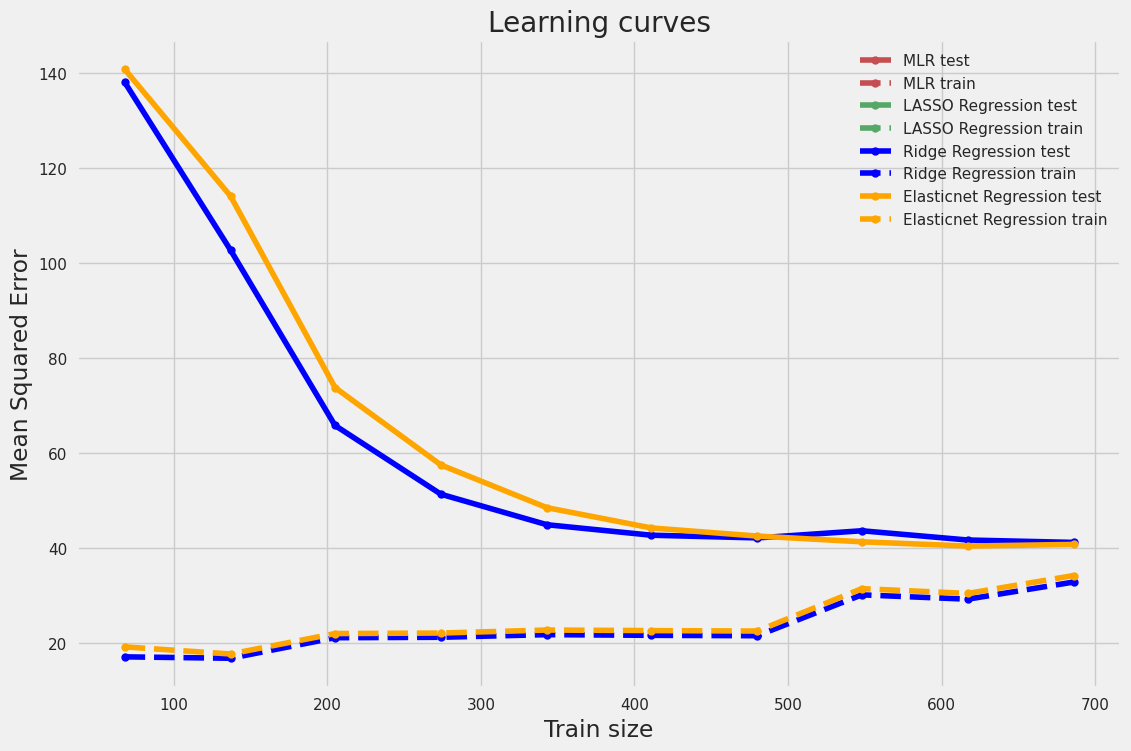

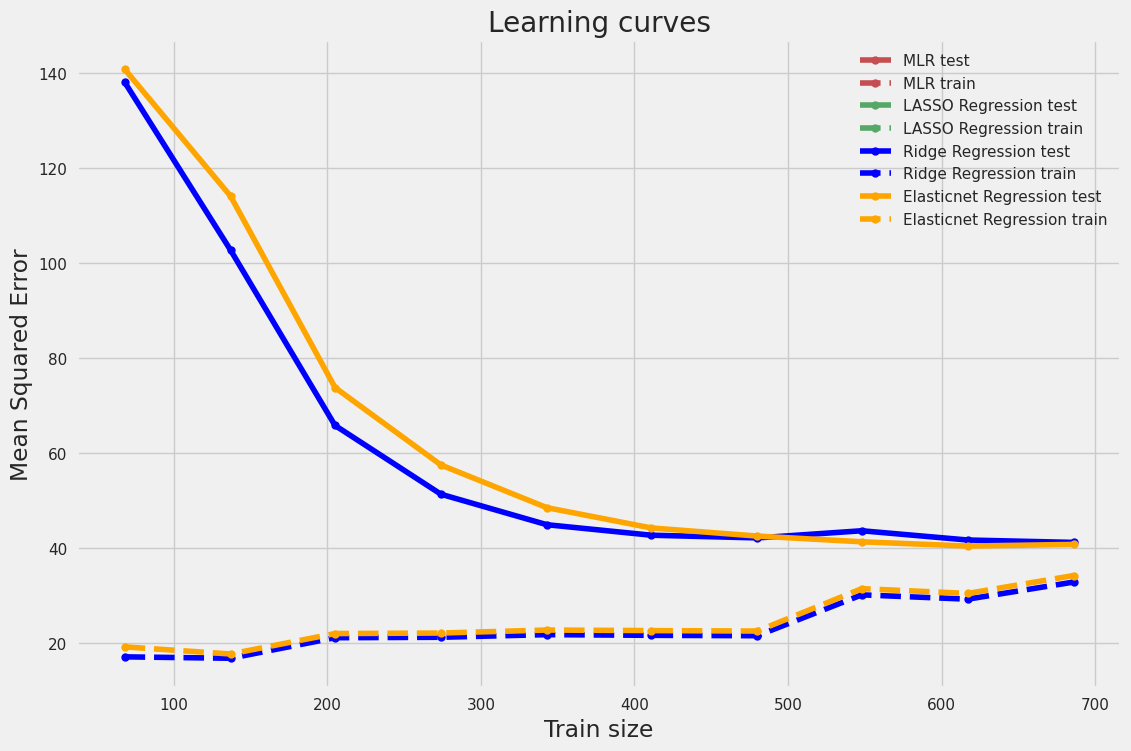

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn import metrics
from sklearn import linear_model
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import GridSearchCV
MLR = imbpipeline(steps = [['scaler', StandardScaler()],
                                ['scaler', linear_model.LinearRegression()]])

lasso = imbpipeline(steps = [['scaler',StandardScaler()],
                                ['scaler',Lasso(alpha=0.5)]])

ridge = imbpipeline(steps = [['scaler', StandardScaler()],
                                ['regressor', Ridge(alpha=0.5)]])

elasticnet = imbpipeline(steps =[ ['scaler',StandardScaler()],
                                ['regressor', ElasticNet(alpha=0.25, l1_ratio=0.5)]])

train_sizes, train_scores_MLR, test_scores_MLR = learning_curve(
    MLR,
    X,
    y,
    train_sizes=np.linspace(0.1, 1, 10),
    scoring="neg_mean_squared_error",
    cv=5,
)
train_sizes_abs, train_scores_lasso, test_scores_lasso = learning_curve(
    lasso,
    X,
    y,
    train_sizes=np.linspace(0.1, 1, 10),
    scoring="neg_mean_squared_error",
    cv=5,
)
train_sizes_abs, train_scores_ridge, test_scores_ridge = learning_curve(
    ridge,
    X,
    y,
    train_sizes=np.linspace(0.1, 1, 10),
    scoring="neg_mean_squared_error",
    cv=5,
)
train_sizes_abs, train_scores_elasticnet, test_scores_elasticnet = learning_curve(
    elasticnet,
    X,
    y,
    train_sizes=np.linspace(0.1, 1, 10),
    scoring="neg_mean_squared_error",
    cv=5,
)

# Figure size
plt.rcParams["figure.figsize"] = (12,8)
plt.figure()

plt.plot(train_sizes, -test_scores_MLR.mean(1), "o-", color="r", label="MLR test")
plt.plot(train_sizes, -train_scores_MLR.mean(1), "o--", color="r", label="MLR train")
plt.plot(train_sizes, -test_scores_lasso.mean(1), "o-", color="g", label="LASSO Regression test")
plt.plot(train_sizes, -train_scores_lasso.mean(1), "o--", color="g", label="LASSO Regression train")
plt.plot(train_sizes, -test_scores_ridge.mean(1), "o-", color="blue", label="Ridge Regression test")
plt.plot(train_sizes, -train_scores_ridge.mean(1), "o--", color="blue", label="Ridge Regression train")
plt.plot(train_sizes, -test_scores_elasticnet.mean(1), "o-", color="orange", label="Elasticnet Regression test")
plt.plot(train_sizes, -train_scores_elasticnet.mean(1), "o--", color="orange", label="Elasticnet Regression train")
plt.xlabel("Train size")
plt.ylabel("Mean Squared Error")
plt.title("Learning curves")
plt.legend(loc="best")

%matplotlib inline
plt.show()


#Low-Code PyCaret

In [ ]:
!pip install tpot
import pandas as pd
from sklearn.model_selection import train_test_split
from tpot import TPOTRegressor


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.9/139.9 kB 11.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for stopit: filename=stopit-1.1.2-py3-none-any.whl size=11938 sha256=ec33fefd2cf5ec278fe9b4a6b6a130903092d1a81783ce16f8d61dc646df26f5
  Stored in directory: /root/.cache/pip/wheels/af/f9/87/bf5b3d565c2a007b4dae9d8142dccc85a9f164e517062dd519
Successfully built stopit


In [ ]:
!pip install -q pycaret autoviz psynlig
from pycaret.regression import *

In [ ]:
!pip install --upgrade openpyxl

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 8.4 MB/s eta 0:00:00
  Attempting uninstall: openpyxl
    Found existing installation: openpyxl 3.0.10
    Uninstalling openpyxl-3.0.10:
      Successfully uninstalled openpyxl-3.0.10


In [ ]:
import re

# Remove special characters from feature names
df.columns = [re.sub('[^A-Za-z0-9]+', '', col) for col in df.columns]


,Description,Value
0,Session id,123
1,Target,Age
2,Target type,Regression
3,Original data shape,"(858, 33)"
4,Transformed data shape,"(858, 7)"
5,Transformed train set shape,"(600, 7)"
6,Transformed test set shape,"(258, 7)"
7,Numeric features,32
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,4.2214,37.5925,6.0952,0.5117,0.1869,0.1512,0.4400
ridge,Ridge Regression,4.4476,40.3863,6.3275,0.4688,0.1996,0.1621,0.1240
lr,Linear Regression,4.4462,40.3870,6.3277,0.4687,0.1995,0.1620,1.2520
lar,Least Angle Regression,4.4462,40.3870,6.3277,0.4687,0.1995,0.1620,0.1360
br,Bayesian Ridge,4.4553,40.3946,6.3277,0.4691,0.1996,0.1626,0.2020
huber,Huber Regressor,4.2242,41.0597,6.3774,0.4632,0.1986,0.1463,0.1020
rf,Random Forest Regressor,4.5118,42.9091,6.5237,0.4359,0.2051,0.1637,0.4240
lightgbm,Light Gradient Boosting Machine,4.4247,43.0894,6.5415,0.4359,0.2010,0.1596,0.1340
knn,K Neighbors Regressor,4.5887,44.6040,6.6298,0.4278,0.2061,0.1626,0.1040
llar,Lasso Least Angle Regression,4.9620,44.7272,6.6519,0.4189,0.2153,0.1876,0.3200


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,4.1787,26.5268,5.1504,0.5018,0.1937,0.1748
1,4.9586,60.0299,7.7479,0.4359,0.2102,0.1691
2,4.7067,49.2949,7.0210,0.4324,0.2034,0.1693
3,4.7899,48.6422,6.9744,0.3999,0.2181,0.1825
4,4.6538,35.9620,5.9968,0.4286,0.2017,0.1752
Mean,4.6576,44.0912,6.5781,0.4397,0.2054,0.1742
Std,0.2607,11.6312,0.9053,0.0336,0.0082,0.0049


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

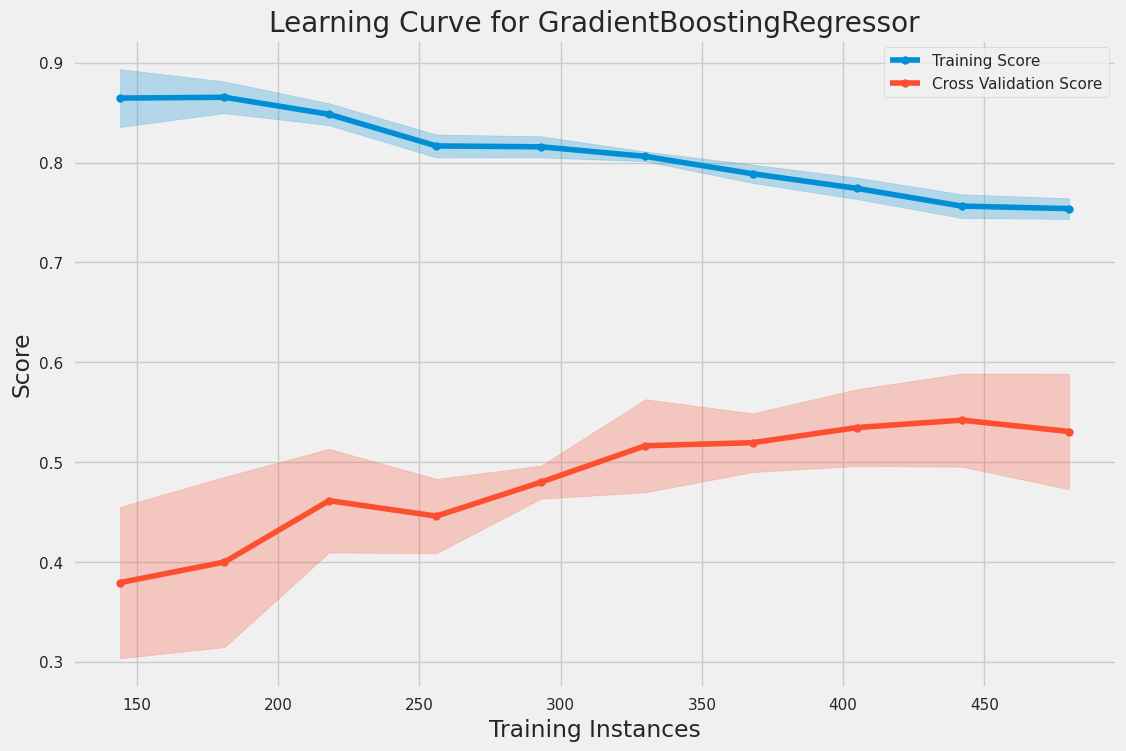

In [ ]:
# PyCaret Low-Code Regressor

# initialize setup
regression = setup(data=df, target='Age',fold=5,
                  normalize=True,
                   feature_selection=True, session_id = 123)

# Compare multiple models and select the best one
best_model = compare_models(sort='MSE')   # run the horse race

# Tune the model using a grid search
tuned_model = tune_model(best_model)  #tune hyperparameters of the best model

# Evaluate the performance of the tuned model
evaluate_model(tuned_model)            # Get KPIs of muned model

# plot learning curve
plot_model(tuned_model, plot='learning')    # Plot the learning curve
%matplotlib inline
plt.show()